File to view plots and mess around with interesting results without having to run code I don't care about for this purpose.


In [2]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Get the directory where you are currently working
current_path = os.getcwd()

# Join it with '..' to go up one level to the main folder
parent_path = os.path.abspath(os.path.join(current_path, '..'))

# Add it to sys.path
if parent_path not in sys.path:
    sys.path.insert(0, parent_path)

import numpy as np
import scipy as sp
from conversions import cm_to_m, erg_to_joule
from rr_escape import get_rr_escape_diagnostics, examine_atmosphere_for_rr_escape
from atmospheres.atmosphere_setting import Atmosphere
from bulk_param_examination import make_simple_atmosphere, sweep_masses, sweep_fluxes, sweep_coeffs
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from atmospheres.simple_H2 import atm_H2






<>:61: SyntaxWarning: invalid escape sequence '\o'
<>:61: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_43148\2791432275.py:61: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('Planetary Mass [$M_\oplus$]', fontsize=14)


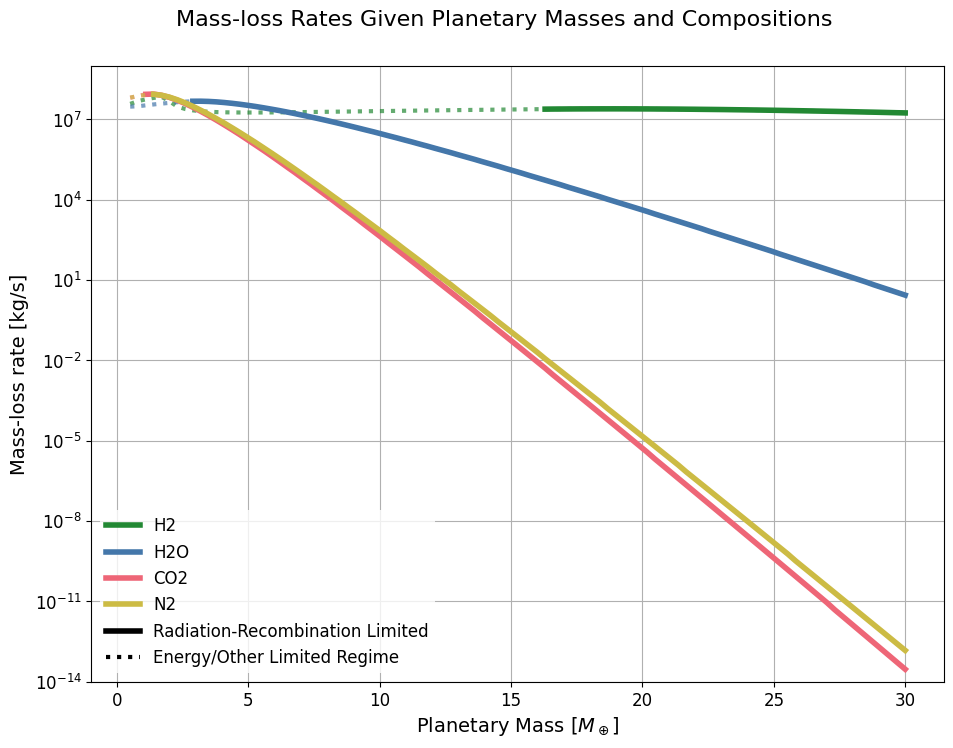

Mass loss rate for H2: 3.8e+07 kg/s


In [7]:
#I want to plot and compare how planets of different compositions


### Want to examine how planetary mass affects mass loss rate ###
M_earth = 5.9722 * 10**24               #[kg]        mass of the earth
Mass_array = np.linspace(0.5, 30, 100, endpoint=True) * M_earth #[kg] array of planetary masses from 0.5 to 30 times the mass of the earth


species_microphysics = {
    #NB, these are the values for the singly ionised and fully dissociated equivalents!!!!!
    'H2': {'nu_0': 3.288467085473 * 10**15, 'mu_wind': 0.5, 'mu_plus_wind': 1, 'mu_photo': 2},
    'H2O': {'nu_0': 4.835981008048 * 10**15 , 'mu_wind': 3, 'mu_plus_wind': 6, 'mu_photo': 18},
    'CO2' : {'nu_0' : 3.3368 * 10**15, 'mu_wind': 7.2, 'mu_plus_wind': 14.4, 'mu_photo': (12+(16*2))}, 
    'N2' : {'nu_0' : 3.7721 * 10**15, 'mu_wind': 7, 'mu_plus_wind': 14, 'mu_photo': 14*2}
    }

atmospheres_swept_varied_mass = {}
for species in species_microphysics.keys(): #for each species
    atms_varied_mass = np.array([make_simple_atmosphere( #make at atmosphere where only the mass is varied
        M_p=m,
        R_p=2.73 * 6.371 * 10**6,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        resolution=10000,
        dominant_species=species) for m in Mass_array])

    #now we have an array of atmospheres with different masses, we can sweep through them and get the mass loss rates and check if it is rr_limited
    M_dot_rr, regime_break, rr_mask = sweep_masses(atms_varied_mass)
    atmospheres_swept_varied_mass[species] = (M_dot_rr, regime_break, rr_mask)


keys = list(atmospheres_swept_varied_mass.keys())

colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44']
fig, ax = plt.subplots(1, 1, figsize=(11, 8))
fig.suptitle('Mass-loss Rates Given Planetary Masses and Compositions', fontsize=16, y=0.95)
masses = Mass_array / M_earth

for i, species in enumerate(keys):
    mass_loss_rates, regime_break, rr_mask = atmospheres_swept_varied_mass[species]
    #plotting the whole mass loss rate curve as dotted first
    ax.plot(masses, mass_loss_rates, linestyle='dotted', color=colours[i], alpha=0.7, lw=3)
    #then plotting the part that is rr_limited as solid
    ax.plot(masses[rr_mask], np.array(mass_loss_rates)[rr_mask], linestyle='solid', color=colours[i], label=f'{species}', lw=4)

custom_lines = [Line2D([0], [0], color='black', linestyle='-', lw=4),
                Line2D([0], [0], color='black', linestyle=':', lw=3)]

# Get current handles and append our style definitions to the legend
handles, labels = ax.get_legend_handles_labels()
handles.extend(custom_lines)
labels.extend(['Radiation-Recombination Limited', 'Energy/Other Limited Regime'])
ax.legend(handles=handles, labels=labels, loc='best', fontsize=12, frameon=True, shadow=False, facecolor='white', edgecolor='none')
ax.grid(True)
ax.set_xlabel('Planetary Mass [$M_\oplus$]', fontsize=14)
ax.set_ylabel('Mass-loss rate [kg/s]', fontsize=14)
# increase size and number of ticks
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis='both', which='minor', labelsize=10)
ax.set_yscale('log')
ax.set_ylim(10**(-14), 10**9)
plt.savefig('Keepers/Mass_sweep.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Mass loss rate for {keys[0]}: {atmospheres_swept_varied_mass[keys[0]][0][0]:.2g} kg/s')


<>:40: SyntaxWarning: invalid escape sequence '\o'
<>:40: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_38556\507562778.py:40: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('Planetary Mass [$M_\oplus$]')


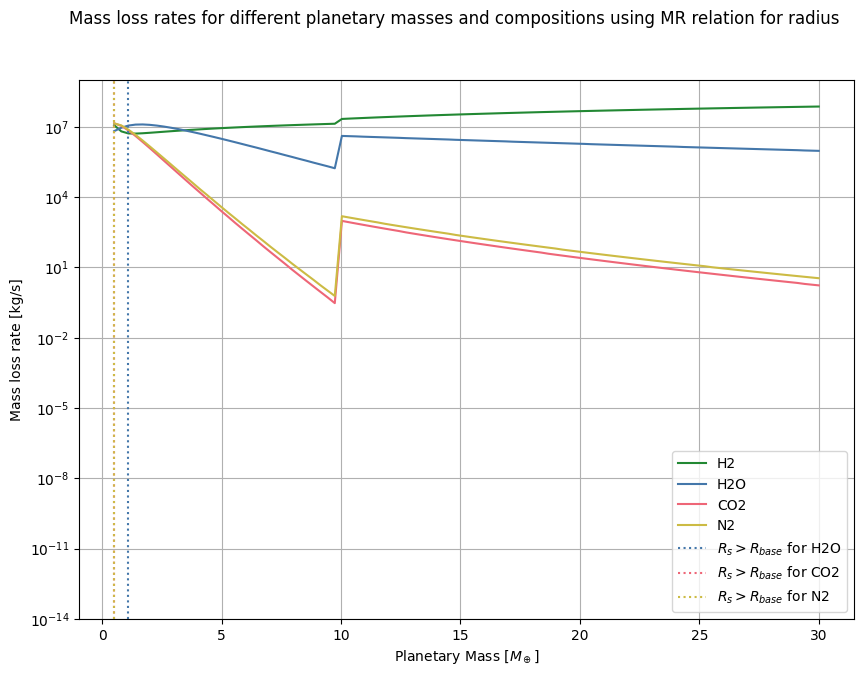

GJ1214b radius from MR relation: 1.2e+07 m
Actual GJ1214b radius: 1.8e+07 m
Mass loss rate for H2 with MR relation: 1.2e+07 kg/s


In [ ]:
atmospheres_swept_varied_mass_MR = {}
for species in species_microphysics.keys(): #for each species
    atms_varied_mass_MR = np.array([make_simple_atmosphere( #make at atmosphere where only the mass is varied, but now the radius is determined by an MR relation
        M_p=m,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        dominant_species=species,
        resolution=10000,
        determine_radius=True) for m in Mass_array])

    #now we have an array of atmospheres with different masses, we can sweep through them and get the mass loss rates and check if it is rr_limited
    M_dot_rr, regime_break, rr_mask = sweep_masses(atms_varied_mass_MR)
    atmospheres_swept_varied_mass_MR[species] = (M_dot_rr, regime_break, rr_mask)


keys = list(atmospheres_swept_varied_mass_MR.keys())

colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44']
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Mass loss rates for different planetary masses and compositions using MR relation for radius')
masses = Mass_array / M_earth
ax.plot(masses, atmospheres_swept_varied_mass_MR[keys[0]][0], label=keys[0], color=colours[0])
ax.plot(masses, atmospheres_swept_varied_mass_MR[keys[1]][0], label=keys[1], color=colours[1])
ax.plot(masses, atmospheres_swept_varied_mass_MR[keys[2]][0], label=keys[2], color=colours[2])
ax.plot(masses, atmospheres_swept_varied_mass_MR[keys[3]][0], label=keys[3], color=colours[3])

for i, ele in enumerate(keys):
    regime_break_index = atmospheres_swept_varied_mass_MR[keys[i]][1]
    if regime_break_index is not None:
        ax.axvline(masses[atmospheres_swept_varied_mass_MR[keys[i]][1]], label=f'$R_s > R_{{base}}$ for {keys[i]}', color=colours[i], linestyle='dotted')

ax.legend()
ax.grid(True)
ax.set_xlabel('Planetary Mass [$M_\oplus$]')
ax.set_ylim(10**(-14), 10**9)
ax.set_ylabel('Mass loss rate [kg/s]')
ax.set_yscale('log')
plt.savefig('Keepers/Mass_sweep_MR.png', dpi=300)
plt.show()

gj1214b_radius_MR = Atmosphere.determine_radius_from_MR_relation(8.41 * 5.9722 * 10**24 )
print(f'GJ1214b radius from MR relation: {gj1214b_radius_MR:.2g} m')
print(f'Actual GJ1214b radius: {2.85 * 6.371 * 10**6:.2g} m')

print(f'Mass loss rate for {keys[0]} with MR relation: {atmospheres_swept_varied_mass_MR[keys[0]][0][0]:.2g} kg/s')


<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_38556\53485112.py:14: SyntaxWarning: invalid escape sequence '\c'
  ax.scatter(MR_masses[low_mass_mask], radii[low_mass_mask], label='R = $1.02 \cdot M_{{p,\oplus}}^{0.28}$', color='#0072b2')
C:\Users\malin\AppData\Local\Temp\ipykernel_38556\53485112.py:15: SyntaxWarning: invalid escape sequence '\c'
  ax.scatter(MR_masses[intermediate_mass_mask], radii[intermediate_mass_mask], label='R = $0.61 \cdot M_{{p,\oplus}}^{0.67}$', color='#cc79a7')


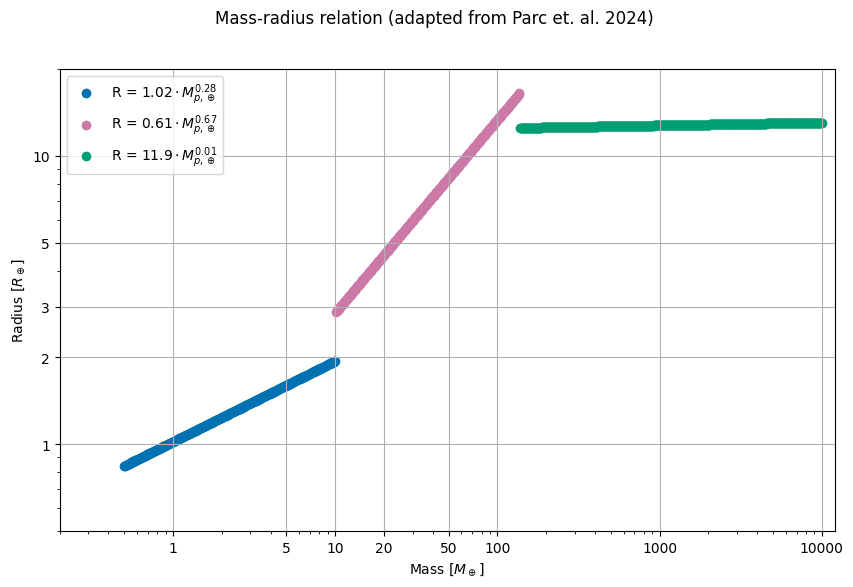

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))
fig.suptitle('Mass-radius relation (adapted from Parc et. al. 2024)')
#Setting up the masses and radii we want to plot the relation of
R_earth = 6371000 #[m] mean earth radius
MR_masses = np.logspace(-0.3, 4, 1000) #[M_earth]
radii = np.array([Atmosphere.determine_radius_from_MR_relation(m)/R_earth for m in (MR_masses * M_earth)])

#Creating the masks
low_mass_mask = MR_masses < 10 #needs to be divided by earth masses again because the comparison is in earth masses
intermediate_mass_mask =  (MR_masses >= 10) & (MR_masses < 138)
high_mass_mask = MR_masses >= 138

#plotting the masks
ax.scatter(MR_masses[low_mass_mask], radii[low_mass_mask], label='R = $1.02 \cdot M_{{p,\oplus}}^{0.28}$', color='#0072b2')
ax.scatter(MR_masses[intermediate_mass_mask], radii[intermediate_mass_mask], label='R = $0.61 \cdot M_{{p,\oplus}}^{0.67}$', color='#cc79a7')
ax.scatter(MR_masses[high_mass_mask], radii[high_mass_mask], label='R = $11.9 \cdot M_{{p,\oplus}}^{0.01}$', color='#009e73')

#Switching axes to log scales
ax.set_xscale('log')
ax.set_yscale('log')

#Defineing and forcing the exact tick marks seen in the paper by Parc et. al. 2024
x_ticks = [1, 5, 10, 20, 50, 100, 1000, 10000]
ax.set_xticks(x_ticks, labels=[str(x) for x in x_ticks])

y_ticks = [1, 2, 3, 5, 10]
ax.set_yticks(y_ticks, labels=[str(y) for y in y_ticks])

#Sets limits to frame the data like the paper's plot bounds
ax.set_xlim(0.2, 12000)
ax.set_ylim(0.5, 20)
ax.set_xlabel('Mass [$M_\oplus$]')
ax.set_ylabel('Radius [$R_\oplus$]')
ax.grid()
ax.legend()
#plt.savefig('Keepers/MR_relation.png', dpi=300)
plt.show()
plt.close(fig)

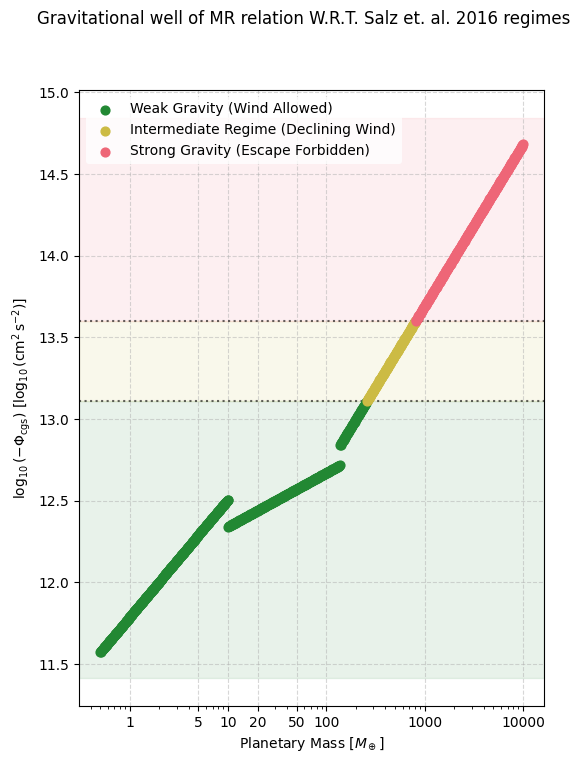

In [5]:
### Want to see how the gravitational well changes with the MR relation ###

### compare with salz et al 2016 if can host hydrodynamic escape ###
G = sp.constants.G #[m^3 kg^-1 s^-2]

grav_pot_SI = np.array([- G * m / Atmosphere.determine_radius_from_MR_relation(m) for m in (MR_masses * M_earth)]) #[m^2 s^-2] gravitational potential at the planetary radius, where G: gravitational constant, M_p: planetary mass, R_p: planetary radius
grav_pot_cgs = grav_pot_SI * cm_to_m**(-2) #[cm^2 s^-2] gravitational potential at the planetary radius in cgs units, where grav_pot_SI: gravitational potential at the planetary radius in SI units
grav_compare = np.log10(-grav_pot_cgs) #[log10(cm^2 s^-2)] logarithm of the negative gravitational potential at the planetary radius in cgs units, where grav_pot_cgs: gravitational potential at the planetary radius in cgs units
salz_strong_grav_threshold = 13.6 #Larger than this value and gravity is too high for hydrodynamic escape. No EL and no wind for RR. REFERENCE Salz et. al. 2016
salz_weak_grav_threshold = 13.11 #Smaller than this value and the planet can host hydrodynamic wind and therefore EL and RR.

fig, ax = plt.subplots(1, 1, figsize=(6, 8))
fig.suptitle('Gravitational well of MR relation W.R.T. Salz et. al. 2016 regimes')

#Masks for the three possible regimes for the atmospheres:
weak_grav_mask = grav_compare < salz_weak_grav_threshold
strong_grav_mask = grav_compare > salz_strong_grav_threshold
intermediate_mask = (grav_compare >= salz_weak_grav_threshold) & (grav_compare <= salz_strong_grav_threshold)

ax.scatter(MR_masses[weak_grav_mask], grav_compare[weak_grav_mask], 
           color='#228833', s=40, zorder=3, label='Weak Gravity (Wind Allowed)')

ax.scatter(MR_masses[intermediate_mask], grav_compare[intermediate_mask], 
           color='#CCBB44', s=40, zorder=3, label='Intermediate Regime (Declining Wind)')

ax.scatter(MR_masses[strong_grav_mask], grav_compare[strong_grav_mask], 
           color='#EE6677', s=40, zorder=3, label='Strong Gravity (Escape Forbidden)')

#Visual Enhancements: Add Threshold Lines and Shading 
ax.axhline(salz_weak_grav_threshold, color='black', linestyle=':', alpha=0.6, zorder=2)
ax.axhline(salz_strong_grav_threshold, color='black', linestyle=':', alpha=0.6, zorder=2)

# Soft background color shading for each area
ax.axhspan(ax.get_ylim()[0], salz_weak_grav_threshold, color='#228833', alpha=0.1, zorder=1)
ax.axhspan(salz_weak_grav_threshold, salz_strong_grav_threshold, color='#CCBB44', alpha=0.1, zorder=1)
ax.axhspan(salz_strong_grav_threshold, ax.get_ylim()[1], color='#EE6677', alpha=0.1, zorder=1)

#5 Labels and Formatting
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_xlabel(r'Planetary Mass [$M_\oplus$]')
ax.set_ylabel(r'$\log_{10}(-\Phi_\mathrm{cgs})$ [$\log_{10}(\mathrm{cm}^2\,\mathrm{s}^{-2})$]')
ax.semilogx()
x_ticks = [1, 5, 10, 20, 50, 100, 1000, 10000]
ax.set_xticks(x_ticks, labels=[str(x) for x in x_ticks])
# Place the legend in a clean spot
ax.legend(loc='best', frameon=True, shadow=False, facecolor='white', edgecolor='none')
ax.grid(True)
#plt.savefig('Keepers/GravPotential_vs_Regime_MR_relation.png', dpi=300)
plt.show()
plt.close()

<>:42: SyntaxWarning: invalid escape sequence '\o'
<>:42: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_38556\1895223830.py:42: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('Planetary Mass [$M_\oplus$]')


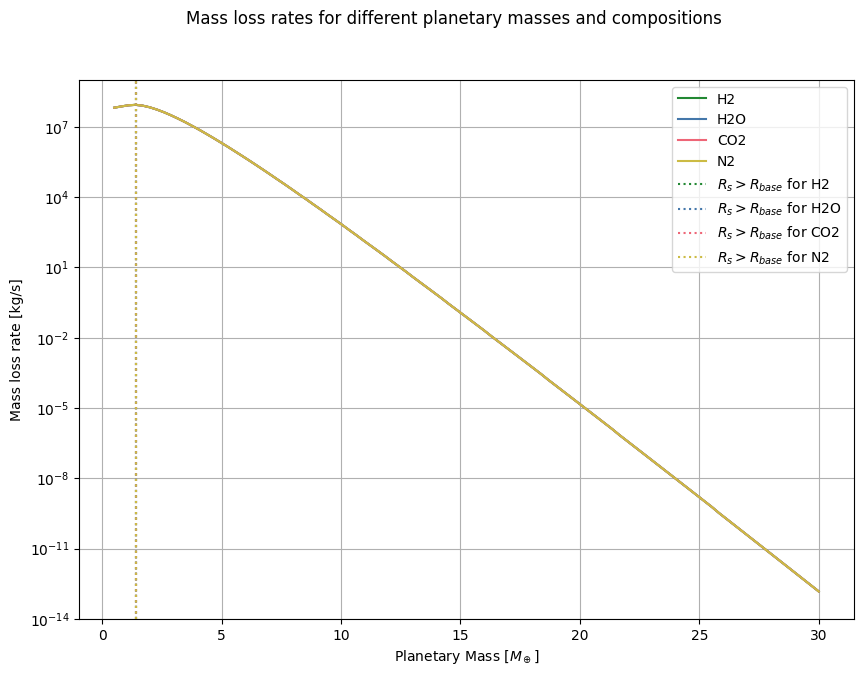

In [6]:
F_earth_xuv = 0.2196388835   #[W/m^2] XUV flux on Earth
Flux_array_xuv = np.logspace(0, 3, 10000) * F_earth_xuv #[W/m^2]
atmospheres_swept_varied_flux = {}
for species in species_microphysics.keys(): #for each species
    atms_varied_flux = np.array([make_simple_atmosphere( #make at atmosphere where only the mass is varied
        M_p=8.41 * 5.9722 * 10**24,
        R_p=2.73 * 6.371 * 10**6,
        F_xuv=F,
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        resolution=10000,
        dominant_species=species) for F in Flux_array_xuv])

    #now we have an array of atmospheres with different masses, we can sweep through them and get the mass loss rates and check if it is rr_limited
    M_dot_rr, regime_break = sweep_masses(atms_varied_mass)
    atmospheres_swept_varied_mass[species] = (M_dot_rr, regime_break)


keys = list(atmospheres_swept_varied_mass.keys())

colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44']
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Mass loss rates for different planetary masses and compositions')
masses = Mass_array / M_earth
ax.plot(masses, atmospheres_swept_varied_mass[keys[0]][0], label=keys[0], color=colours[0])
ax.plot(masses, atmospheres_swept_varied_mass[keys[1]][0], label=keys[1], color=colours[1])
ax.plot(masses, atmospheres_swept_varied_mass[keys[2]][0], label=keys[2], color=colours[2])
ax.plot(masses, atmospheres_swept_varied_mass[keys[3]][0], label=keys[3], color=colours[3])

for i, ele in enumerate(keys):
    regime_break_index = atmospheres_swept_varied_mass[keys[i]][1]
    if regime_break_index is not None:
        ax.axvline(masses[atmospheres_swept_varied_mass[keys[i]][1]], label=f'$R_s > R_{{base}}$ for {keys[i]}', color=colours[i], linestyle='dotted')

ax.legend()
ax.grid(True)
ax.set_xlabel('Planetary Mass [$M_\oplus$]')
ax.set_ylabel('Mass loss rate [kg/s]')
ax.set_yscale('log')
ax.set_ylim(10**(-14), 10**9)
plt.savefig('Keepers/Mass_sweep.png', dpi=300)
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\p'
<>:38: SyntaxWarning: invalid escape sequence '\p'
C:\Users\malin\AppData\Local\Temp\ipykernel_38556\1976024014.py:38: SyntaxWarning: invalid escape sequence '\p'
  ax.plot(alpha_B, (atmospheres_swept_coeffs[keys[0]][0][0] / alpha_B[0]**(-0.5)) * alpha_B**(-0.5), label='$M_{rr} \propto \\alpha_{B}^{-0.5}$', color='black', linestyle='dashed', alpha=0.5)


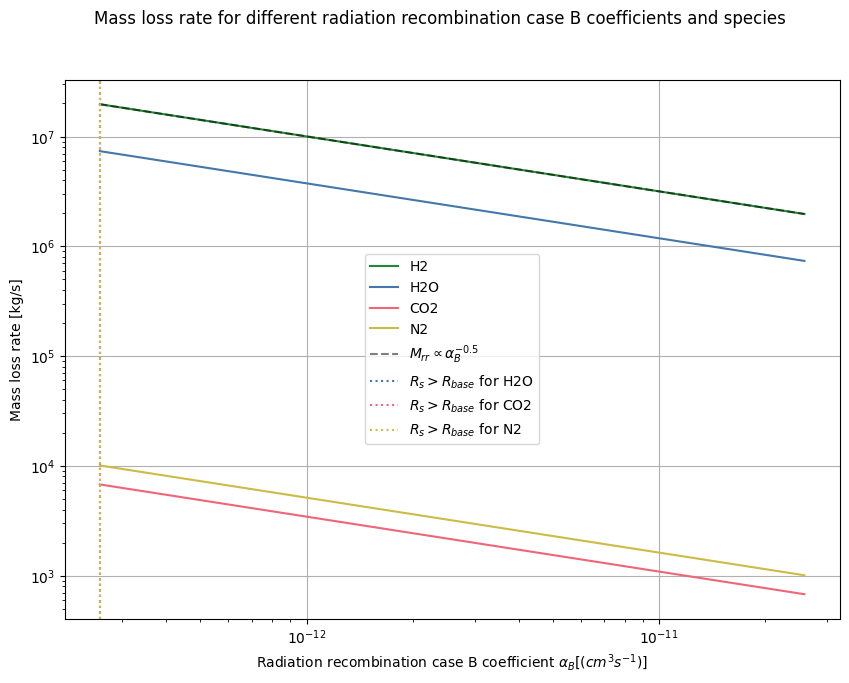

In [7]:
# I want to test the sensitivity of the recombination coefficient when it comes to the RR_escape rate value

#for different species with different coefficients, I want to plot the escape rate as a function of the recombination coefficient

alpha_B = np.linspace(2.59 * 10**(-13), 2.59 * 10**(-11), 100) #[cm^3 s^-1] start is based on singly ionised hydrogen alpha_B, end is based on O IX alpha_B. Just to test if its worth implementing exact values.

atmospheres_swept_coeffs = {}
for species in species_microphysics.keys(): #See dictionary defined above for the microphysical parameters of each species in the second cell
    atm_varied_coeff = np.array([make_simple_atmosphere(
        M_p=8.41 * 5.9722 * 10**24,
        R_p=2.73 * 6.371 * 10**6,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        T_eq=553,
        mu_photo=species_microphysics[species]['mu_photo'],
        P_0=2000,
        T_wind=10**4,
        dominant_species=species,
        rr_coeff=a #input in cm^3 s^-1, but is converted inside the function for escape rate calculation to m^3 s^-1
    ) for a in alpha_B])
    
    rates, r_break = sweep_coeffs(atm_varied_coeff)
    atmospheres_swept_coeffs[species] = (rates, r_break)

keys = list(atmospheres_swept_coeffs.keys())


colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44']
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Mass loss rate for different radiation recombination case B coefficients and species')

ax.plot(alpha_B, atmospheres_swept_coeffs[keys[0]][0], label=keys[0], color=colours[0])
ax.plot(alpha_B, atmospheres_swept_coeffs[keys[1]][0], label=keys[1], color=colours[1])
ax.plot(alpha_B, atmospheres_swept_coeffs[keys[2]][0], label=keys[2], color=colours[2])
ax.plot(alpha_B, atmospheres_swept_coeffs[keys[3]][0], label=keys[3], color=colours[3])
ax.plot(alpha_B, (atmospheres_swept_coeffs[keys[0]][0][0] / alpha_B[0]**(-0.5)) * alpha_B**(-0.5), label='$M_{rr} \propto \\alpha_{B}^{-0.5}$', color='black', linestyle='dashed', alpha=0.5)

for i, ele in enumerate(keys):
    regime_break_index = atmospheres_swept_coeffs[keys[i]][1]
    if regime_break_index is not None:
        ax.axvline(alpha_B[atmospheres_swept_coeffs[keys[i]][1]], label=f'$R_s > R_{{base}}$ for {keys[i]}', color=colours[i], linestyle='dotted')

ax.legend()
ax.grid(True)
ax.set_xlabel('Radiation recombination case B coefficient $\\alpha_{B} [(cm^3 s^{-1})]$')
ax.set_ylabel('Mass loss rate [kg/s]')
ax.set_xscale('log')
ax.set_yscale('log')
#plt.savefig('Keepers/RR_coeff_sensitivity.png', dpi=300)
plt.show()

    

In [8]:


atmospheres = {}
for species in species_microphysics.keys():
    atm = np.array([make_simple_atmosphere(
        M_p=8.41 * 5.9722 * 10**24,
        R_p=2.73 * 6.371 * 10**6,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        T_eq=553,
        mu_photo=species_microphysics[species]['mu_photo'],
        P_0=2000,
        T_wind=10**4,
        dominant_species=species)
        ])
    atmospheres[species] = atm

for species in atmospheres.keys():
    examine_atmosphere_for_rr_escape(atmospheres[species][0])

Examining the following atmosphere:
Dominant species at the base of the escaping atmosphere: H2
Dominant species used to set wind parameters: False
Bulk properties: M_p = 5e+25 kg, R_p = 1.7e+07 m, F_xuv = 0.85 W/m^2
Wind properties: T_wind = 1e+04 K, mu_wind = 0.50, nu_0 = 3.29e+15 Hz, mu_plus_wind = 1.00
Photosphere properties: P_0 = 2e+03 Pa, T_eq = 5.5e+02 K

Planet can host hydrodynamic escape through wind: 12.284965810498718 < 13.11 (log10(grav pot [cm^2 s^-2])

Escape diagnostics for the atmosphere:
Using values from this P_base: 0.0001 Pa
R_base: 2.2e+07 m
c_s: 1.3e+04 m/s
R_s: 2.2e+07 m
Is it RR-limited? False
The calculated sonic point radius was 1e+07 m
rho_s: 2.5e-13 kg/m^3
Escape rate: 1.9e+07 kg/s
Examining the following atmosphere:
Dominant species at the base of the escaping atmosphere: H2O
Dominant species used to set wind parameters: False
Bulk properties: M_p = 5e+25 kg, R_p = 1.7e+07 m, F_xuv = 0.85 W/m^2
Wind properties: T_wind = 1e+04 K, mu_wind = 3.00, nu_0 = 4.8